## Prevendo preço de fechamento de ações com modelo Long-Short term memory (LSTM) de redes neurais recorrentes

### 0. Introdução

O objetivo desse projeto é implementar um modelo LSTM de redes neurais recorrentes para prever o preço de fechamentos de ações. Os dados de atividade financeira a serem analisados serão obtidos a partir da biblioteca **yfinance**. De posse dos dados, a primeira etapa consistirá de análise exploratória dos dados visando ganhar familiriaridade com as informações providas pela **yfinance** (*exploratory data analysis*). Na sequência, serão discutidas práticas de análise e manipulação de valores faltantes e anomalias (*data wrangling*). Por fim, a etapa final consistirá em implementar o modelo LSTM usando a biblioteca *tensorflow* nos dados previamente explorados e corrigidos.

In [1]:
import numpy as np # para manipulação de arranjos e vetores
import pandas as pd # para manipular os dados estruturados
import seaborn as sns # importante para uma melhor visualização de dados
import yfinance as yf # biblioteca usada para extrair dados financeiros
import matplotlib.pyplot as plt # biblioteca padrão para plotagem de gráficos
import plotly.graph_objects as go # biblioteca alternativa para plotagem de gráficos
from sklearn.preprocessing import MinMaxScaler # utilizado para normalizar dados (necessário para implementação do modelo)
from sklearn.metrics import mean_squared_error, mean_absolute_error # metricas para avaliar performance dos modelos
from statsmodels.tsa.stattools import adfuller

# Funções para implementação do modelo de deep learning LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import RootMeanSquaredError, MeanSquaredError
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator


In [2]:
def create_sequences(data_array, target_index, seq_len=60):
    """
    data_array: numpy array of shape (N, num_features)
    target_index: column index of target within features
    seq_len: length of the input sequence (timesteps)

    returns: X, y
        X.shape = (num_samples, seq_len, num_features)
        y.shape = (num_samples,)
    """
    X, y = [], []
    for i in range(seq_len, len(data_array)):
        X.append(data_array[i-seq_len:i])             # previous seq_len days
        y.append(data_array[i, target_index])         # target at day i
    return np.array(X), np.array(y)


### 1. Exploratory data analysis (EDA)

Serão analisados os dados da empresa Petrobra (variável `company`) no período entre 01/01/2015 (`start`) a 31/12/2023 (`end`).

In [3]:
# empresa cujos proeços de ações serão analisados
company='PETR4.SA'

# Início do período a ser analisado
start = '2015-01-01' 

# Fim do período a ser analisado
end = '2024-12-31'

# importando dados usando a biblioteca yfinance (yf)
data = yf.download(company, start=start, end=end)

C:\Users\josea\AppData\Local\Temp\ipykernel_21796\3561607524.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(company, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


In [4]:
print(f"##### Data for {company} #####")
data.head()

##### Data for PETR4.SA #####


Price,Close,High,Low,Open,Volume
Ticker,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA,PETR4.SA
Date,,,,,
2015-01-02,2.572509,2.745659,2.569761,2.745659,49559500
2015-01-05,2.352637,2.525786,2.344391,2.512044,78385100
2015-01-06,2.275681,2.426843,2.209719,2.393863,84723300
2015-01-07,2.382870,2.399360,2.297669,2.352638,85531000
2015-01-08,2.536780,2.580755,2.402108,2.415850,83306300


In [5]:
type(data.columns[0])

tuple

Nota-se que as colunas da tabela estão nomeadas usando uma lista de tuplas, o que não é conveniente para a manipulação de dados. 

In [6]:
print(f"##### Renaming columns #####")
data.columns = [col[0] for col in data.columns]
# printar primeiros 5 itens da tabela
data.head()


##### Renaming columns #####


,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,2.572509,2.745659,2.569761,2.745659,49559500
2015-01-05,2.352637,2.525786,2.344391,2.512044,78385100
2015-01-06,2.275681,2.426843,2.209719,2.393863,84723300
2015-01-07,2.382870,2.399360,2.297669,2.352638,85531000
2015-01-08,2.536780,2.580755,2.402108,2.415850,83306300


In [7]:
# printar nomes ajustados das tabelas
print(data.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [8]:
# printar 5 últimos itens da tabela
data.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2024-12-20,32.877815,33.323919,32.752907,33.154401,59277400
2024-12-23,32.886738,33.056256,32.761829,33.011646,43785600
2024-12-26,33.133961,33.347011,32.976487,33.004278,22920700
2024-12-27,33.032066,33.347010,32.985752,33.347010,24167200
2024-12-30,33.523006,33.689742,33.133960,33.143221,22355600


In [9]:
data = data.reset_index('Date')
data['Date'] = pd.to_datetime(data['Date']) #realizando a conversão da data para formato datetime
data.head()

,Date,Close,High,Low,Open,Volume
0,2015-01-02,2.572509,2.745659,2.569761,2.745659,49559500
1,2015-01-05,2.352637,2.525786,2.344391,2.512044,78385100
2,2015-01-06,2.275681,2.426843,2.209719,2.393863,84723300
3,2015-01-07,2.382870,2.399360,2.297669,2.352638,85531000
4,2015-01-08,2.536780,2.580755,2.402108,2.415850,83306300


In [10]:
print(f"##### Data frame Shape {company} #####")
data.shape

##### Data frame Shape PETR4.SA #####


(2487, 6)

Uma primeira avaliação de dados pode ser feita utilizando a função `info` da biblioteca **pandas**; essa função retorna parâmetros importantes relacionados aos dados, incluindo número de entradas (linhas) e de colunas, tipo de dados em cada coluna, etc. 

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2487 entries, 0 to 2486
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2487 non-null   datetime64[ns]
 1   Close   2487 non-null   float64       
 2   High    2487 non-null   float64       
 3   Low     2487 non-null   float64       
 4   Open    2487 non-null   float64       
 5   Volume  2487 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 116.7 KB


Uma segunda etapa de EDA pode ser feita usando a função `describe` também do `pandas`.  Essa função retorna informações estastística dos dados da tabela como média, desvio padrão, quartis, e mínimo e máximo. 

In [12]:
data.describe()

,Date,Close,High,Low,Open,Volume
count,2487,2487.000000,2487.000000,2487.000000,2487.000000,2.487000e+03
mean,2020-01-01 23:19:28.154403072,10.386522,10.531496,10.242653,10.387910,5.998208e+07
min,2015-01-02 00:00:00,1.154331,1.173570,1.132344,1.154331,0.000000e+00
25%,2017-07-05 12:00:00,4.174877,4.251786,4.118488,4.177579,3.844015e+07
50%,2020-01-02 00:00:00,7.319808,7.411558,7.200060,7.310581,5.295610e+07
75%,2022-07-05 12:00:00,13.332482,13.523451,13.026732,13.273888,7.286525e+07
max,2024-12-30 00:00:00,34.830193,34.976068,34.418304,34.624248,4.902304e+08
std,NaN,8.833332,8.916765,8.745509,8.827816,3.325824e+07


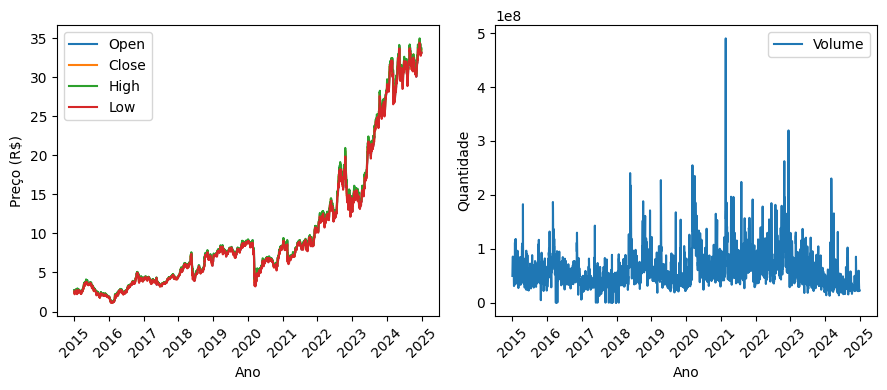

In [13]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(9,4))

ax1.plot(data["Date"], data["Open"], label="Open")
ax1.plot(data["Date"], data["Close"], label="Close")
ax1.plot(data["Date"], data["High"], label="High")
ax1.plot(data["Date"], data["Low"], label="Low")
ax1.set_xlabel("Ano")
ax1.set_ylabel("Preço (R$)")
ax1.tick_params(axis="x", rotation=45)
ax1.legend()

ax2.plot(data["Date"], data["Volume"], label="Volume")
ax2.set_xlabel("Ano")
ax2.set_ylabel("Quantidade")
ax2.tick_params(axis="x", rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()

Com base nas figuras, as séries temporais de dados não apresentam anomalias evidentes.

É importante também avaliar a quantidade de elementos faltantes na tabela

In [14]:
print(data.apply(np.isnan).sum())


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


Surpreendentemente, não há elementos faltantes em nenhuma das colunas.

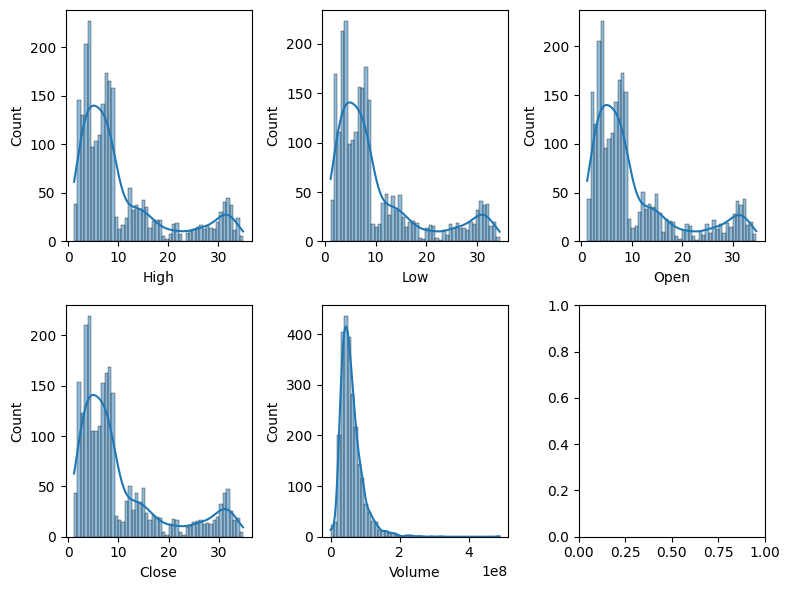

In [15]:
fig, axs = plt.subplots(2,3, figsize=(8,6))
sns.histplot(data['High'], bins=50, kde=True, ax=axs[0,0])
sns.histplot(data['Low'], bins=50, kde=True, ax=axs[0,1])
sns.histplot(data['Open'], bins=50, kde=True, ax=axs[0,2])
sns.histplot(data['Close'], bins=50, kde=True, ax=axs[1,0])
sns.histplot(data['Volume'], bins=50, kde=True, ax=axs[1,1])

plt.tight_layout()
plt.show()


As distribuições de "high", "low" "open" e "close" são bem semelhantes, indicando forte correlação entre essas variáveis. O mapa de correlação das variáveis abaixo confirma isso.

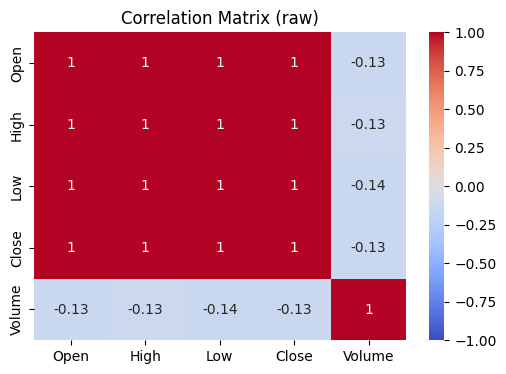

In [16]:
plt.figure(figsize=(6, 4))
corr = data[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix (raw)")
plt.show()


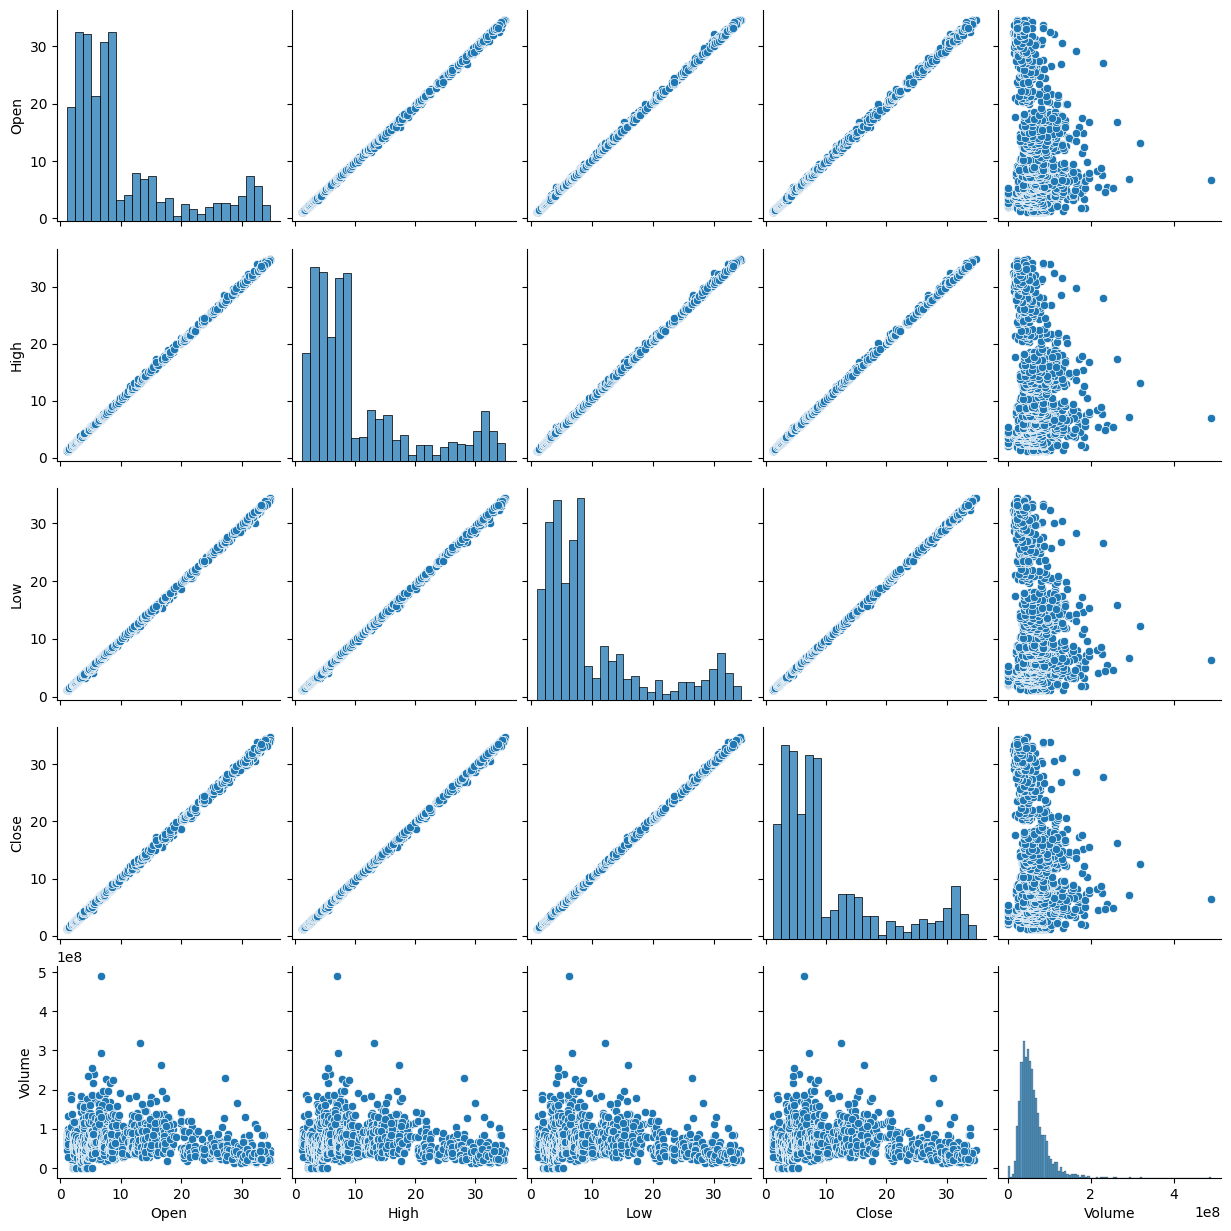

In [17]:
sns.pairplot(data[['Open', 'High', 'Low', 'Close', 'Volume']])
plt.show()


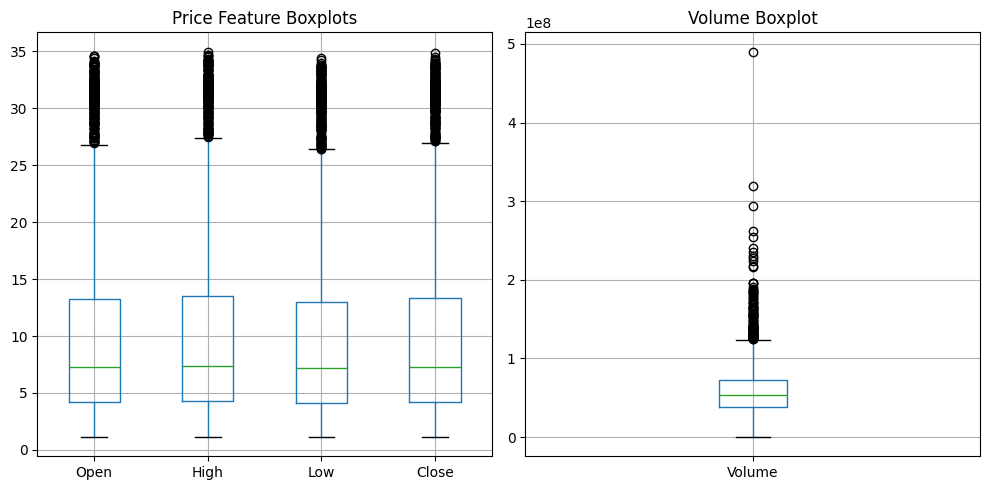

In [18]:
# Split columns
price_cols = ['Open', 'High', 'Low', 'Close']
volume_col = ['Volume']

# Create figure and axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Boxplot for price-related features
data[price_cols].boxplot(ax=ax1)
ax1.set_title("Price Feature Boxplots")

# Boxplot for volume
data[volume_col].boxplot(ax=ax2)
ax2.set_title("Volume Boxplot")

plt.tight_layout()
plt.show()


### 2. Data preprocessing

Duvida:

* Mudar o número de colunas incluidas no algoritmo muda alguma coisa?

In [19]:
data_model = data.copy()

data_model['Date'] = pd.to_datetime(data_model['Date'])
data_model.drop(columns=['Open','High','Low','Volume'], inplace=True)
data_model.head()

,Date,Close
0,2015-01-02,2.572509
1,2015-01-05,2.352637
2,2015-01-06,2.275681
3,2015-01-07,2.382870
4,2015-01-08,2.536780


In [20]:
## transformar lista de valores em vetor 
close_data = data_model['Close'].values
close_data = close_data.reshape(-1,1) 

## normalizar os dados
scaler = MinMaxScaler(feature_range=(0,1))
scaler = scaler.fit(close_data)
close_data = scaler.transform(close_data)

# type(close_data_scaled)

In [21]:
split_percent = 0.80
split = int(split_percent*len((close_data)))

close_train = close_data[:split]
close_test = close_data[split:]

date_train = data_model['Date'][:split]
date_test = data_model['Date'][split:]

print(len(date_train))
print(len(date_test))

1989
498


In [22]:
## definir janela de dias passados
look_back = 10 

train_generator = TimeseriesGenerator(close_train, close_train, length=look_back, batch_size=20)
test_generator = TimeseriesGenerator(close_test, close_test, length=look_back, batch_size=1)

In [23]:
np.random.seed(42)

model = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(look_back,1)),
    Dense(1),  # valor final previsto para a classe "Close"
])

model.compile(optimizer='adam', loss='mse', metrics=[MeanSquaredError()])

history = model.fit(train_generator, epochs=20, verbose=1)

Epoch 1/20


d:\tech_challenge_fase_4\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0080 - mean_squared_error: 0.0080
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0026 - mean_squared_error: 0.0026
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0018 - mean_squared_error: 0.0018
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0013 - mean_squared_error: 0.0013
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - mean_squared_error: 0.0011
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.0973e-04 - mean_squared_error: 9.0973e-04
Epoch 7/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.4555e-04 - mean_squared_error: 8.4555e-04
Epoch 8/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.6036e-04 - mean_squared_error: 6.6036e-04
Epoch 9/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.1527e-04 - mean_squared_error: 6.1527e-04
Epoch 10/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.6802e-04 - mean_squared_error: 5.6802e-04
Epoch 11/20
99/99 ━━━━━━━━━━━━

In [24]:
# Avaliando o modelo nos dados de teste
mse = model.evaluate(test_generator, verbose=1)
print("Erro Quadrático Médio", mse[0])

488/488 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0048 - mean_squared_error: 0.0048
Erro Quadrático Médio 0.0047789402306079865


In [25]:
# encerrada a etapa de treinamento, vamos avaliar as previsões do modelo
test_pred = model.predict(test_generator)

488/488 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [26]:
# 1. Fazer previsões usando o conjunto de teste
test_predictions = model.predict(test_generator)

# 2. Inverter qualquer transformação aplicada aos dados
test_predictions_inv = scaler.inverse_transform(test_predictions.reshape(-1, 1))
test_actuals_inv = scaler.inverse_transform(np.array(close_test).reshape(-1, 1))

# Ajuste as dimensões
test_actuals_inv = test_actuals_inv[:len(test_predictions_inv)]

# Calcular o MAPE
mape = np.mean(np.abs((test_actuals_inv - test_predictions_inv) / test_actuals_inv)) * 100

# Imprimir o MAPE
print(f"MAPE: {mape:.2f}%")

488/488 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


ValueError: operands could not be broadcast together with shapes (498,1) (4880,1) 

In [27]:
#O RMSE é a raiz quadrada do MSE (Mean Squared Error), que é a média dos quadrados das diferenças entre as previsões do modelo e os valores reais.
rmse_value = np.sqrt(mse[0])

print("RMSE:", rmse_value)

RMSE: 0.06912987943435159


In [28]:
prediction = model.predict(test_generator)

close_train = close_train.reshape((-1))
close_test = close_test.reshape((-1))
prediction = prediction.reshape((-1))

trace1 = go.Scatter(
    x = date_train,
    y = close_train,
    mode = 'lines',
    name = 'Data'
)
trace2 = go.Scatter(
    x = date_test,
    y = prediction,
    mode = 'lines',
    name = 'Prediction'
)
trace3 = go.Scatter(
    x = date_test,
    y = close_test,
    mode='lines',
    name = 'Ground Truth'
)
layout = go.Layout(
    title = "Predições da Disney",
    xaxis = {'title' : "Data"},
    yaxis = {'title' : "Fechamento"}
)
fig = go.Figure(data=[trace1, trace2, trace3], layout=layout)
fig.show()

488/488 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


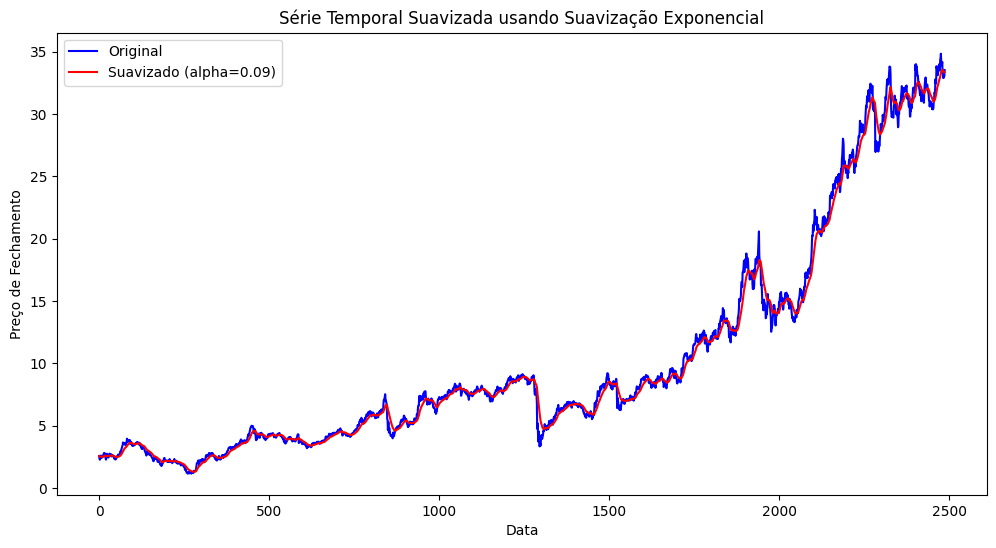

In [29]:
# Suazivando a série temporal
# Aplicando suavização exponencial
alpha = 0.09   # Fator de suavização
# O parâmetro alpha na suavização exponencial controla a taxa de decaimento dos pesos atribuídos às observações passadas.
# Determina o quão rapidamente o impacto das observações antigas diminui à medida que você avança no tempo.

data_model['Smoothed_Close'] = data_model['Close'].ewm(alpha=alpha, adjust=False).mean()

# Visualizando os resultados
plt.figure(figsize=(12, 6))
plt.plot(data_model.index, data_model['Close'], label='Original', color='blue')
plt.plot(data_model.index, data_model['Smoothed_Close'], label=f'Suavizado (alpha={alpha})', color='red')
plt.title('Série Temporal Suavizada usando Suavização Exponencial')
plt.xlabel('Data')
plt.ylabel('Preço de Fechamento')
plt.legend()
plt.show()

In [30]:
# Teste de estacionariedade (ADF Test)
adf_result = adfuller(data_model['Smoothed_Close'] )
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')
print('Resultados do Teste de Estacionariedade:')
print('--------------------------------------')
print('Teste Estatístico:', adf_result[0])
print('Valor-p:', adf_result[1])
print('Valores Críticos:')
for key, value in adf_result[4].items():
    print(f'   {key}: {value}')

ADF Statistic: 1.9707452302283153
p-value: 0.9986337103081865
Resultados do Teste de Estacionariedade:
--------------------------------------
Teste Estatístico: 1.9707452302283153
Valor-p: 0.9986337103081865
Valores Críticos:
   1%: -3.4330034727471475
   5%: -2.8627122832725975
   10%: -2.567394052950918


In [31]:
data_model.drop(columns=['Close'], inplace=True)
data_model.head()

,Date,Smoothed_Close
0,2015-01-02,2.572509
1,2015-01-05,2.552721
2,2015-01-06,2.527787
3,2015-01-07,2.514744
4,2015-01-08,2.516728


In [33]:
close_data = data_model['Smoothed_Close'].values
close_data = close_data.reshape(-1,1) #transformar em array

scaler = MinMaxScaler(feature_range=(0, 1))
scaler = scaler.fit(close_data)
close_data = scaler.transform(close_data)

split_percent = 0.80
split = int(split_percent*len(close_data))

close_train = close_data[:split]
close_test = close_data[split:]

date_train = data_model['Date'][:split]
date_test = data_model['Date'][split:]

print(len(close_train))
print(len(close_test))

1989
498


In [34]:
# Gerar sequências temporais para treinamento e teste em um modelo de aprendizado de máquina

look_back = 5

train_generator = TimeseriesGenerator(close_train, close_train, length=look_back, batch_size=20)
test_generator = TimeseriesGenerator(close_test, close_test, length=look_back, batch_size=1)

In [35]:
from tensorflow.keras.optimizers import Adam

np.random.seed(7)

model = Sequential()
model.add(LSTM(200, activation='relu', input_shape=(look_back,1)))
model.add(Dense(1)),

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=[MeanSquaredError()])

num_epochs = 100
model.fit(train_generator, epochs=num_epochs, verbose=1)

Epoch 1/100


d:\tech_challenge_fase_4\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0043 - mean_squared_error: 0.0043
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.4924e-05 - mean_squared_error: 6.4924e-05
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.4555e-05 - mean_squared_error: 6.4555e-05
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.0339e-05 - mean_squared_error: 6.0339e-05
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.6895e-05 - mean_squared_error: 7.6895e-05
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.1051e-05 - mean_squared_error: 4.1051e-05
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.5583e-05 - mean_squared_error: 8.5583e-05
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.2224e-05 - mean_squared_error: 6.2224e-05
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.6895e-05 - mean_squared_error: 8.6895e-05
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.4777e-05 -

In [36]:
# 1. Fazer previsões usando o conjunto de teste
test_predictions = model.predict(test_generator)

# 2. Inverter qualquer transformação aplicada aos dados
test_predictions_inv = scaler.inverse_transform(test_predictions.reshape(-1, 1))
test_actuals_inv = scaler.inverse_transform(np.array(close_test).reshape(-1, 1))

# Ajuste as dimensões
test_actuals_inv = test_actuals_inv[:len(test_predictions_inv)]

# Calcular o MAPE
mape = np.mean(np.abs((test_actuals_inv - test_predictions_inv) / test_actuals_inv)) * 100

# Imprimir o MAPE
print(f"MAPE: {mape:.2f}%")

493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
MAPE: 1.98%


In [37]:
# Avaliando o modelo nos dados de teste
mse = model.evaluate(test_generator, verbose=1)
print("Erro Quadrático Médio:", mse[0])

493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.7779e-04 - mean_squared_error: 5.7779e-04
Erro Quadrático Médio: 0.0005777936312370002


In [38]:
# O RMSE é a raiz quadrada do MSE (Mean Squared Error), que é a média dos quadrados das diferenças entre as previsões do modelo e os valores reais.
rmse_value = np.sqrt(mse[0])

print("RMSE:", rmse_value)

RMSE: 0.024037338272716476


In [40]:
prediction = model.predict(test_generator)

close_train = close_train.reshape((-1))
close_test = close_test.reshape((-1))
prediction = prediction.reshape((-1))

trace1 = go.Scatter(
    x = date_train,
    y = close_train,
    mode = 'lines',
    name = 'Data'
)
trace2 = go.Scatter(
    x = date_test,
    y = prediction,
    mode = 'lines',
    name = 'Prediction'
)
trace3 = go.Scatter(
    x = date_test,
    y = close_test,
    mode='lines',
    name = 'Ground Truth'
)
layout = go.Layout(
    title = "Predições da Petrobras",
    xaxis = {'title' : "Data"},
    yaxis = {'title' : "Fechamento"}
)
fig = go.Figure(data=[trace1, trace2, trace3], layout=layout)
fig.show()

493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [42]:
close_data = close_data.reshape((-1))


# Função para prever os próximos 'num_prediction' pontos da série temporal
# Utiliza o modelo treinado para prever cada ponto sequencialmente
# A cada iteração, adiciona a previsão à lista 'prediction_list'

def predict(num_prediction, model):
    prediction_list = close_data[-look_back:]

    for _ in range(num_prediction):
        x = prediction_list[-look_back:]
        x = x.reshape((1, look_back, 1))
        out = model.predict(x)[0][0]
        prediction_list = np.append(prediction_list, out)
    prediction_list = prediction_list[look_back-1:]

    return prediction_list

# Função para gerar as datas dos próximos 'num_prediction' dias
# Assume que o DataFrame 'df' possui uma coluna 'Date' contendo as datas

def predict_dates(num_prediction):
    last_date = data_model['Date'].values[-1]
    prediction_dates = pd.date_range(last_date, periods=num_prediction+1).tolist()
    return prediction_dates

num_prediction = 15 #definição dos próximos dias
forecast = predict(num_prediction, model) #resultado de novos dias
forecast_dates = predict_dates(num_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


In [43]:
trace1 = go.Scatter(
    x = date_test,
    y = close_test,
    mode = 'lines',
    name = 'Data'
)
trace2 = go.Scatter(
    x = forecast_dates,
    y = forecast,
    mode = 'lines',
    name = 'Prediction'
)
layout = go.Layout(
    title = "Forecast Disney",
    xaxis = {'title' : "Data"},
    yaxis = {'title' : "Fechamento"}
)
fig = go.Figure(data=[trace1, trace2], layout=layout)
fig.show()

In [44]:
df = pd.DataFrame(data_model)
df_past = df[['Date','Smoothed_Close']]
df_past.rename(columns={'Smoothed_Close': 'Actual'}, inplace=True)         #criando nome das colunas
df_past['Date'] = pd.to_datetime(df_past['Date'])                          #configurando para datatime
df_past['Forecast'] = np.nan                                               #Preenchendo com NAs
df_past['Forecast'].iloc[-1] = df_past['Actual'].iloc[-1]
df_past.head(3)

C:\Users\josea\AppData\Local\Temp\ipykernel_21796\1079420325.py:6: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


C:\Users\josea\AppData\Local\Temp\ipykernel_21796\1079420325.py:6: SettingWithCopyWarning:


A value is trying to be set on a co

,Date,Actual,Forecast
0,2015-01-02,2.572509,NaN
1,2015-01-05,2.552721,NaN
2,2015-01-06,2.527787,NaN


In [45]:
# Faz a transformação inversa das predições
forecast = forecast.reshape(-1, 1) #reshape para array
forecast = scaler.inverse_transform(forecast) # retransformando os dados para escala real

In [46]:
df_future = pd.DataFrame(columns=['Date', 'Actual', 'Forecast'])
df_future['Date'] = forecast_dates
df_future['Forecast'] = forecast.flatten()
df_future['Actual'] = np.nan
df_future.head()

,Date,Actual,Forecast
0,2024-12-30,NaN,33.345126
1,2024-12-31,NaN,32.217008
2,2025-01-01,NaN,31.518035
3,2025-01-02,NaN,30.754287
4,2025-01-03,NaN,30.079164


In [47]:
# Garantir que a coluna 'Date' seja datetime em ambos os DataFrames
df_past['Date'] = pd.to_datetime(df_past['Date'])
df_future['Date'] = pd.to_datetime(df_future['Date'])

# Concatenar os DataFrames
frames = [df_past, df_future]
results = pd.concat(frames, ignore_index=True)

# Definir 'Date' como índice e ordenar
results = results.set_index('Date').sort_index()

# Visualizar o resultado
results.head()

,Actual,Forecast
Date,,
2015-01-02,2.572509,NaN
2015-01-05,2.552721,NaN
2015-01-06,2.527787,NaN
2015-01-07,2.514744,NaN
2015-01-08,2.516728,NaN


In [ ]:
# data frame a ser utilizado no modelo
data_model = data.copy()

feature_cols = ['Open','High','Low','Volume']
target_col = 'Close'

train_size = int(0.8 * len(data)) # 80% dos dados para treino
val_size = int(0.2 * len(data)) # 20% para validação

# criando training, validation e test sets
train_df = data_model.iloc[:train_size]
val_df = data_model.iloc[train_size:]

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)


In [ ]:
# definir o scaler
scaler = MinMaxScaler(feature_range=(0,1))

# fit apenas nos dados de treino
scaler.fit(train_df[feature_cols])

# aplica transformação em todos os dados
train_scaled = scaler.transform(train_df[feature_cols])
val_scaled = scaler.transform(val_df[feature_cols])

# transformar todos em arranjos numpy para usar no LSTM
train_scaled = np.array(train_scaled)
val_scaled = np.array(val_scaled)


In [ ]:
target_idx = feature_cols.index(target_col)

In [ ]:
# usando a fundao create_sequence criada anterioremente
# criamos um tensor contendo sequencias de dados de 60 dias x N features x numero de batchs
X_train, y_train = create_sequences(train_scaled, target_idx)
X_val,   y_val   = create_sequences(val_scaled,   target_idx)
X_test,  y_test  = create_sequences(test_scaled,  target_idx)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)

### 3. Training the model

In [ ]:
num_features = len(feature_cols)

model = Sequential([
    LSTM(100, activation='relu', return_sequences=True, input_shape=(60,num_features)),
    Dense(1),  # valor final previsto para a classe "Close"
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

In [ ]:
# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True
# )

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=20,
    verbose=1
)

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MSE loss')
plt.title('LSTM Training History')
plt.show()


In [ ]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MSE (scaled):", test_loss)
print("Test MAE (scaled):", test_mae)


In [ ]:
# Predict
y_pred_scaled = model.predict(X_test)

# Prepare empty arrays to inverse-transform
num_test_samples = y_test.shape[0]
num_features = len(feature_cols)

# For y_true
y_test_full = np.zeros((num_test_samples, num_features))
y_test_full[:, target_idx] = y_test

# For y_pred
y_pred_full = np.zeros((num_test_samples, num_features))
y_pred_full[:, target_idx] = y_pred_scaled.reshape(-1)

# Inverse transform
y_test_inv = scaler.inverse_transform(y_test_full)[:, target_idx]
y_pred_inv = scaler.inverse_transform(y_pred_full)[:, target_idx]


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae  = mean_absolute_error(y_test_inv, y_pred_inv)

print("Test RMSE (R$):", rmse)
print("Test MAE  (R$):", mae)


In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label='Real Close')
plt.plot(y_pred_inv, label='Predicted Close')
plt.title("LSTM Predictions vs Actual (PETR4.SA)")
plt.xlabel("Test samples (time ordered)")
plt.ylabel("Close price (R$)")
plt.legend()
plt.show()


In [ ]:
plt.figure(figsize=(14,6))

# 1️ Plot the full Close series
plt.plot(data_model.index, data_model['Close'], label='Full Series', color='gray', alpha=0.6)

# 2️ Build the date index corresponding to test predictions
pred_dates = test_df.index[60:]   # aligns predictions with test timeline

# 3️ Plot actual Close values in the test period
plt.plot(pred_dates, y_test_inv, label='Real Close (test)', color='blue')

# 4️ Plot predicted Close values in the same region
plt.plot(pred_dates, y_pred_inv, label='Predicted Close (test)', color='orange')

# 5️ Finish formatting
plt.title("LSTM Predictions vs Actual Overlaid on Full Series (PETR4.SA)")
plt.xlabel("Date")
plt.ylabel("Close Price (R$)")
plt.legend()
plt.grid(True)
plt.show()
